# 02. Exploratory Data Analysis (EDA)

## Цель
Провести разведочный анализ объединенного датасета `merged_df`, учитывая заранее заданное разбиение на обучающую и тестовую части через колонку `Dataset`.

## Задачи
1. Проверить структуру данных и качество таблицы.
2. Разделить данные на `train_df` и `test_df`.
3. Изучить распределение целевой переменной `Account_Number`.
4. Построить графики и описательную статистику для каждой колонки.
5. Выявить выбросы, дисбаланс классов, особенности текстовых и числовых признаков.
6. Проверить возможные риски утечки таргета.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 200)

In [3]:
def show_basic_info(df, name="DataFrame"):
    display(pd.DataFrame({
        "metric": ["rows", "columns", "duplicates"],
        "value": [df.shape[0], df.shape[1], df.duplicated().sum()]
    }))
    
    missing_df = (
        df.isna()
        .sum()
        .reset_index()
        .rename(columns={"index": "column", 0: "missing_count"})
    )
    missing_df["missing_percent"] = (missing_df["missing_count"] / len(df) * 100).round(2)
    display(missing_df.sort_values("missing_count", ascending=False))

In [4]:
def plot_categorical(df, col, top_n=20, title=None, rotate=75):
    vc = df[col].astype(str).value_counts(dropna=False).head(top_n).reset_index()
    vc.columns = [col, "count"]
    plt.figure(figsize=(12, 5))
    sns.barplot(data=vc, x=col, y="count")
    plt.title(title if title else f"{col}: top {top_n} categories")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=rotate)
    plt.show()
    display(vc)

In [5]:
def plot_numeric(df, col, bins=30, title=None):
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col].dropna(), bins=bins, kde=True)
    plt.title(title if title else f"{col}: distribution")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()
    
    display(df[col].describe().to_frame().T)

In [6]:
def plot_box(df, col, title=None):
    plt.figure(figsize=(10, 3))
    sns.boxplot(x=df[col].dropna())
    plt.title(title if title else f"{col}: boxplot")
    plt.xlabel(col)
    plt.show()

In [7]:
def summarize_text(df, col):
    temp = df[col].astype(str)
    summary = pd.DataFrame({
        "column": [col],
        "non_null_count": [df[col].notna().sum()],
        "unique_count": [df[col].nunique(dropna=True)],
        "avg_length": [temp.str.len().mean()],
        "median_length": [temp.str.len().median()],
        "avg_word_count": [temp.str.split().str.len().mean()],
        "median_word_count": [temp.str.split().str.len().median()]
    })
    display(summary)

In [8]:
def plot_text_lengths(df, col):
    temp = df[col].astype(str)
    lengths = temp.str.len()
    word_counts = temp.str.split().str.len()
    plt.figure(figsize=(10, 5))
    sns.histplot(lengths, bins=30, kde=True)
    plt.title(f"{col}: text length distribution")
    plt.xlabel("Length")
    plt.ylabel("Count")
    plt.show()
    plt.figure(figsize=(10, 5))
    sns.histplot(word_counts, bins=30, kde=True)
    plt.title(f"{col}: word count distribution")
    plt.xlabel("Word count")
    plt.ylabel("Count")
    plt.show()
    display(pd.DataFrame({
        "metric": ["avg_length", "median_length", "avg_word_count", "median_word_count"],
        "value": [lengths.mean(), lengths.median(), word_counts.mean(), word_counts.median()]
    }))

In [9]:
merged_df = pd.read_csv('../data/modified/merged_dataframe.csv')
merged_df.head()

,Dataset,Date,Invoice,Supplier_Code,Supplier_Name,Invoice_Item,Item_Description,Item_Value,Item_Quantity,Total_Amount,Taxes_Credit_%,Taxes_Credit_Amount,Total_Net_Amount,Account_Number,Account_Description,Activity_Code,Activity_Description
0,Training,2019-08-15,91,10001,ABS & ABC Tax Consulting,1,Review of federal tax obligations,2000,1,2000,0,0.0,2000.0,4000010,Audit and Consulting,7020400,"Business management consulting, except specialized technical consulting"
1,Training,2019-08-15,186,10002,HJU Travel Agency,1,Assistance with flight and hotel arrangements,500,1,500,0,0.0,500.0,4000080,Other Third-Party Services,7911200,Travel agencies
2,Training,2019-08-15,275,10003,ABC Associated Lawyers,1,Legal advisory in labor lawsuit,2000,1,2000,0,0.0,2000.0,4000012,Legal Services,6911701,Legal services
3,Training,2019-08-15,135,10004,ATY Business Consulting,1,Consulting on zero-based budgeting,15000,1,15000,0,0.0,15000.0,4000010,Audit and Consulting,7020400,"Business management consulting, except specialized technical consulting"
4,Training,2019-08-15,221,10005,HBG Security and Surveillance,1,Provision of 2 security guards for gate,15000,1,15000,0,0.0,15000.0,4000015,Security and Surveillance,8020001,Electronic security system monitoring activities


In [10]:
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 343 entries, 0 to 342
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Dataset               343 non-null    str    
 1   Date                  343 non-null    str    
 2   Invoice               343 non-null    int64  
 3   Supplier_Code         343 non-null    int64  
 4   Supplier_Name         343 non-null    str    
 5   Invoice_Item          343 non-null    int64  
 6   Item_Description      343 non-null    str    
 7   Item_Value            343 non-null    int64  
 8   Item_Quantity         343 non-null    int64  
 9   Total_Amount          343 non-null    int64  
 10  Taxes_Credit_%        343 non-null    int64  
 11  Taxes_Credit_Amount   343 non-null    float64
 12  Total_Net_Amount      343 non-null    float64
 13  Account_Number        343 non-null    int64  
 14  Account_Description   343 non-null    str    
 15  Activity_Code         343 non-null

In [11]:
print("Полных дубликатов:", merged_df.duplicated().sum())

Полных дубликатов: 0


In [12]:
column_summary = pd.DataFrame({
    "column": merged_df.columns,
    "dtype": merged_df.dtypes.astype(str).values,
    "nunique": [merged_df[col].nunique(dropna=False) for col in merged_df.columns]
})
display(column_summary)

,column,dtype,nunique
0,Dataset,str,2
1,Date,str,53
2,Invoice,int64,303
3,Supplier_Code,int64,27
4,Supplier_Name,str,28
5,Invoice_Item,int64,6
6,Item_Description,str,123
7,Item_Value,int64,79
8,Item_Quantity,int64,25
9,Total_Amount,int64,85


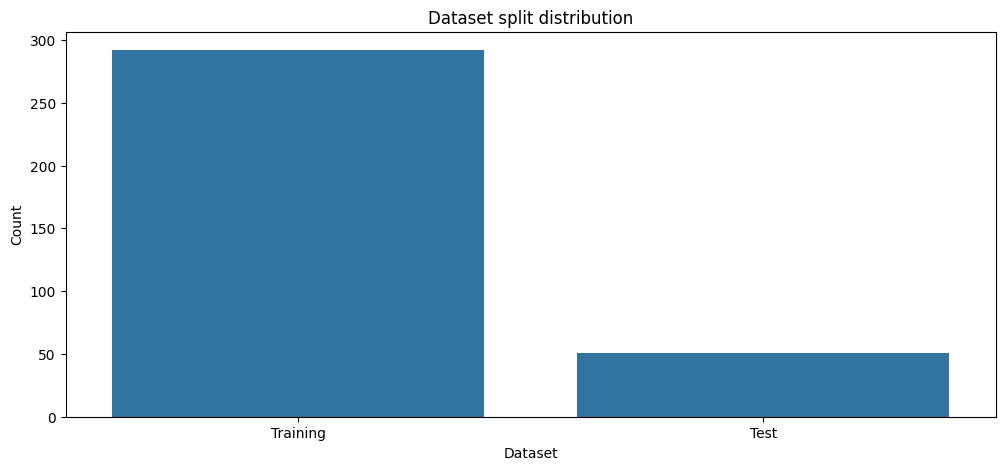

,Dataset,count
0,Training,292
1,Test,51


In [13]:
plot_categorical(merged_df, "Dataset", top_n=10, title="Dataset split distribution", rotate=0)

In [14]:
train_df = merged_df[merged_df["Dataset"] == "Training"].copy()
test_df = merged_df[merged_df["Dataset"] == "Test"].copy()
split_summary = pd.DataFrame({
    "part": ["Training", "Test"],
    "rows": [len(train_df), len(test_df)],
    "unique_accounts": [train_df["Account_Number"].nunique(), test_df["Account_Number"].nunique()],
    "unique_suppliers": [train_df["Supplier_Code"].nunique(), test_df["Supplier_Code"].nunique()]
})

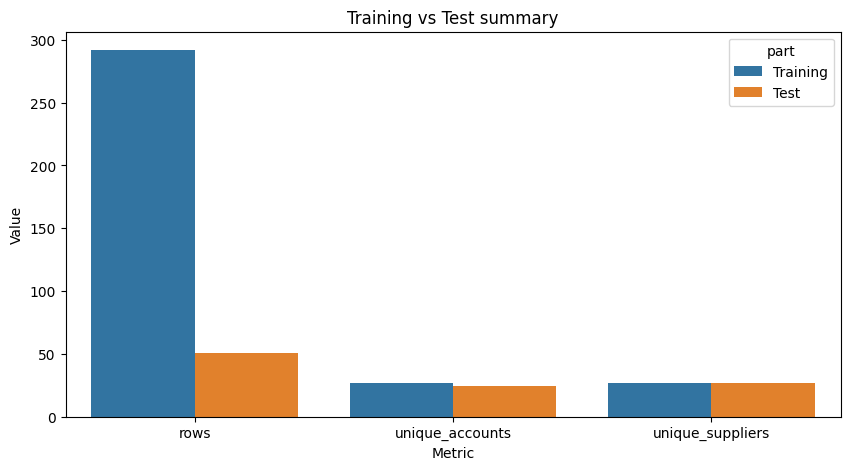

,part,rows,unique_accounts,unique_suppliers
0,Training,292,27,27
1,Test,51,24,27


In [15]:
split_summary_plot = split_summary.melt(id_vars="part", var_name="metric", value_name="value")
plt.figure(figsize=(10, 5))
sns.barplot(data=split_summary_plot, x="metric", y="value", hue="part")
plt.title("Training vs Test summary")
plt.xlabel("Metric")
plt.ylabel("Value")
plt.show()
display(split_summary)

In [16]:
train_classes = set(train_df["Account_Number"].unique())
test_classes = set(test_df["Account_Number"].unique())
class_membership_df = pd.DataFrame({
    "group": ["only_in_train", "only_in_test"],
    "values": [sorted(train_classes - test_classes), sorted(test_classes - train_classes)]
})
display(class_membership_df)

,group,values
0,only_in_train,"[1001002, 4000013, 5000017]"
1,only_in_test,[]


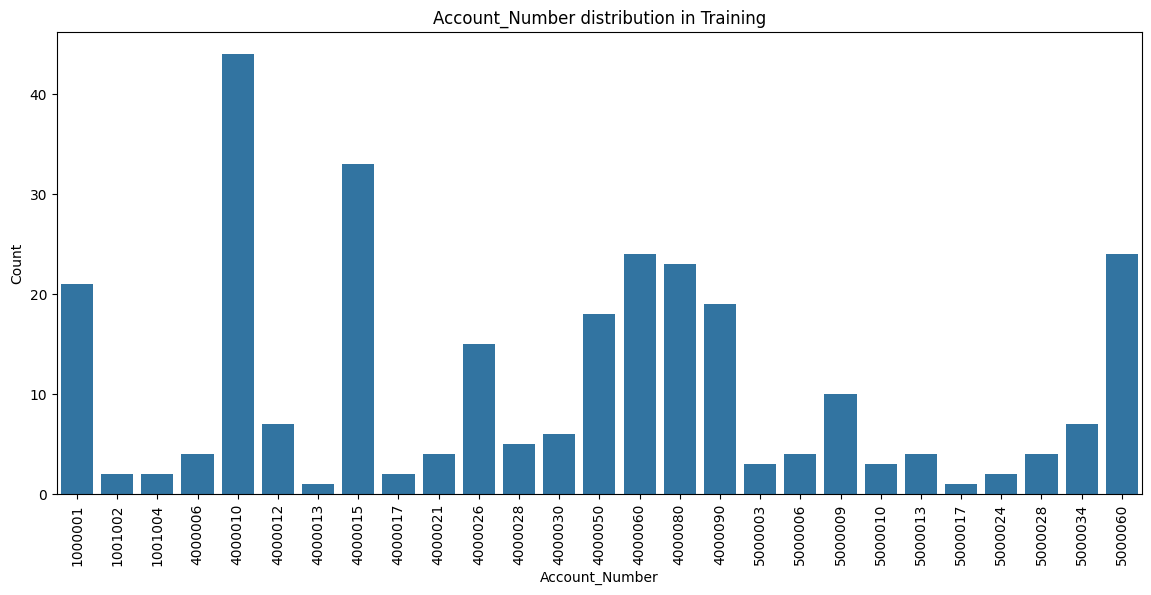

,Account_Number,count
0,4000010,44
1,4000015,33
2,4000060,24
3,5000060,24
4,4000080,23
5,1000001,21
6,4000090,19
7,4000050,18
8,4000026,15
9,5000009,10


In [17]:
train_target_counts = train_df["Account_Number"].value_counts().sort_values(ascending=False).reset_index()
train_target_counts.columns = ["Account_Number", "count"]
plt.figure(figsize=(14, 6))
sns.barplot(data=train_target_counts, x="Account_Number", y="count")
plt.title("Account_Number distribution in Training")
plt.xlabel("Account_Number")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()
display(train_target_counts)

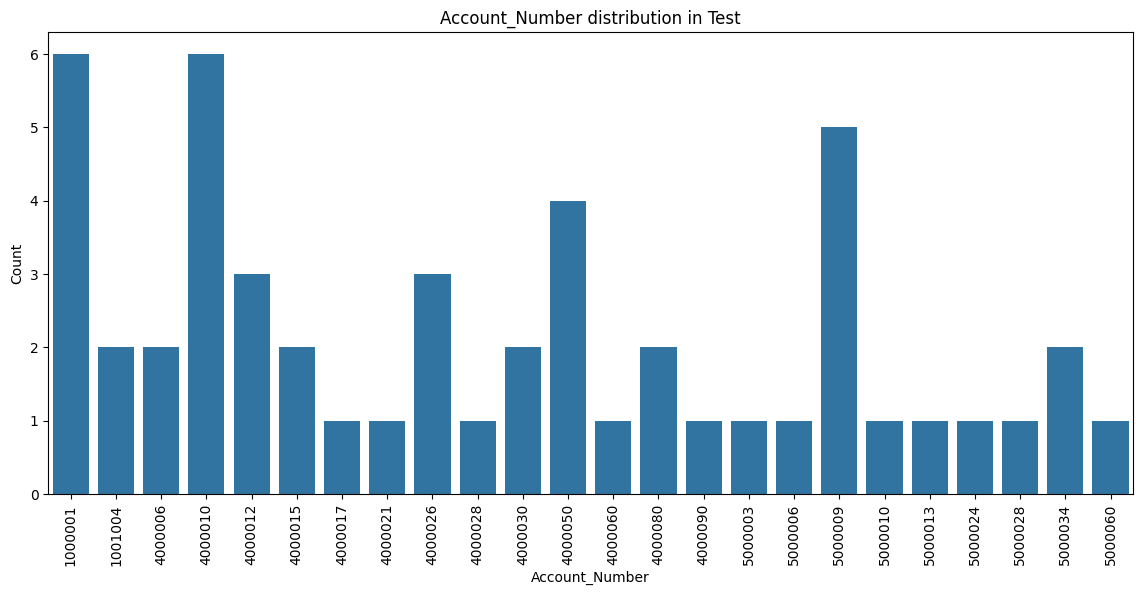

,Account_Number,count
0,4000010,6
1,1000001,6
2,5000009,5
3,4000050,4
4,4000012,3
5,4000026,3
6,4000080,2
7,4000015,2
8,4000030,2
9,1001004,2


In [18]:
test_target_counts = test_df["Account_Number"].value_counts().sort_values(ascending=False).reset_index()
test_target_counts.columns = ["Account_Number", "count"]
plt.figure(figsize=(14, 6))
sns.barplot(data=test_target_counts, x="Account_Number", y="count")
plt.title("Account_Number distribution in Test")
plt.xlabel("Account_Number")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()
display(test_target_counts)

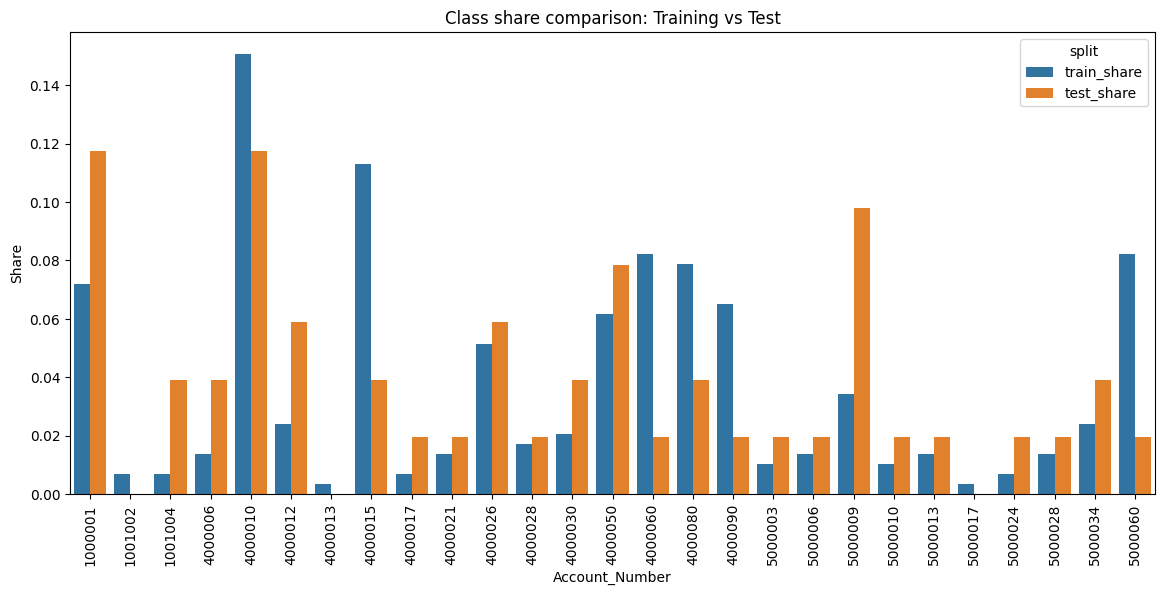

,Account_Number,train_share,test_share
0,4000010,0.150685,0.117647
1,4000015,0.113014,0.039216
2,4000060,0.082192,0.019608
3,5000060,0.082192,0.019608
4,4000080,0.078767,0.039216
5,1000001,0.071918,0.117647
6,4000090,0.065068,0.019608
7,4000050,0.061644,0.078431
8,4000026,0.051370,0.058824
9,5000009,0.034247,0.098039


In [19]:
target_compare = pd.concat([
    train_df["Account_Number"].value_counts(normalize=True).rename("train_share"),
    test_df["Account_Number"].value_counts(normalize=True).rename("test_share")
], axis=1).fillna(0).reset_index()
target_compare.columns = ["Account_Number", "train_share", "test_share"]
target_compare_long = target_compare.melt(
    id_vars="Account_Number",
    value_vars=["train_share", "test_share"],
    var_name="split",
    value_name="share"
)
plt.figure(figsize=(14, 6))
sns.barplot(data=target_compare_long, x="Account_Number", y="share", hue="split")
plt.title("Class share comparison: Training vs Test")
plt.xlabel("Account_Number")
plt.ylabel("Share")
plt.xticks(rotation=90)
plt.show()
display(target_compare.sort_values("train_share", ascending=False))

In [20]:
merged_df["Date"] = pd.to_datetime(merged_df["Date"], errors="coerce")
merged_df["Year"] = merged_df["Date"].dt.year
merged_df["Month"] = merged_df["Date"].dt.month
merged_df["Day"] = merged_df["Date"].dt.day
merged_df["Item_Description_Length"] = merged_df["Item_Description"].astype(str).str.len()
merged_df["Item_Description_Word_Count"] = merged_df["Item_Description"].astype(str).str.split().str.len()
train_df = merged_df[merged_df["Dataset"] == "Training"].copy()
test_df = merged_df[merged_df["Dataset"] == "Test"].copy()

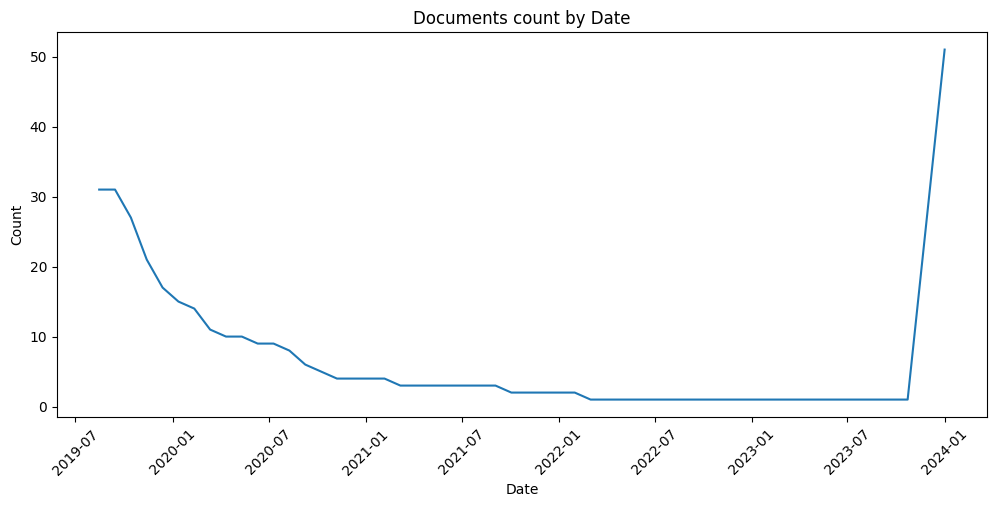

,Date,count
33,2022-05-01,1
34,2022-05-31,1
35,2022-06-30,1
36,2022-07-30,1
37,2022-08-29,1
38,2022-09-28,1
39,2022-10-28,1
40,2022-11-27,1
41,2022-12-27,1
42,2023-01-26,1


In [21]:
date_counts = merged_df["Date"].value_counts().sort_index().reset_index()
date_counts.columns = ["Date", "count"]
plt.figure(figsize=(12, 5))
sns.lineplot(data=date_counts, x="Date", y="count")
plt.title("Documents count by Date")
plt.xlabel("Date")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()
display(date_counts.tail(20))

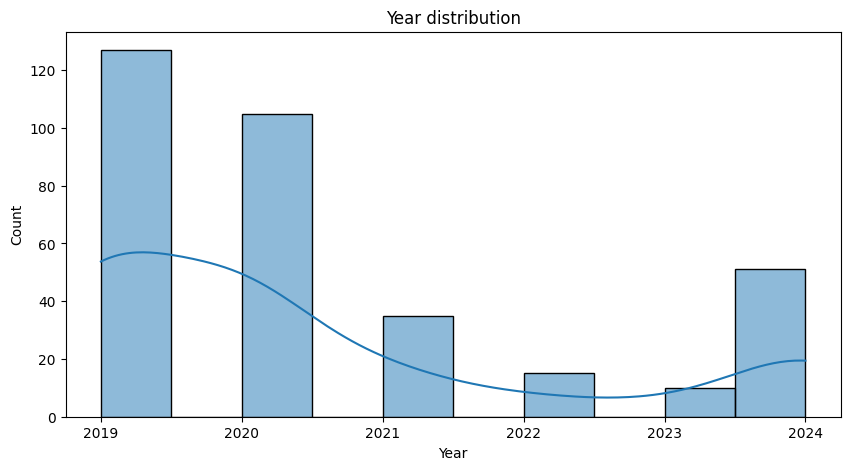

,count,mean,std,min,25%,50%,75%,max
Year,343.0,2020.501458,1.745294,2019.0,2019.0,2020.0,2021.0,2024.0


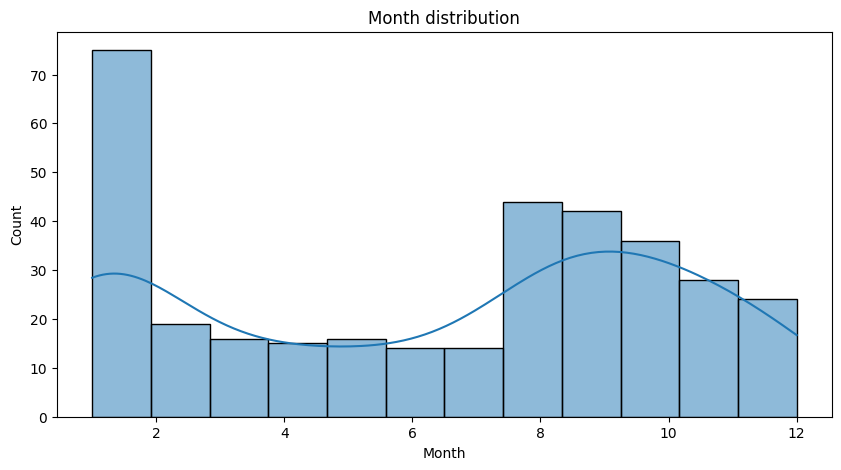

,count,mean,std,min,25%,50%,75%,max
Month,343.0,6.323615,3.850677,1.0,2.0,8.0,10.0,12.0


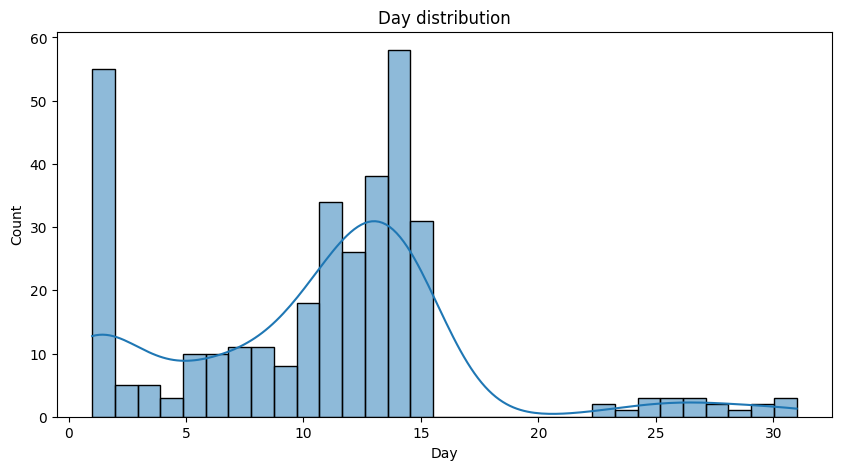

,count,mean,std,min,25%,50%,75%,max
Day,343.0,10.548105,6.339553,1.0,6.0,12.0,14.0,31.0


In [22]:
plot_numeric(merged_df, "Year", bins=10, title="Year distribution")
plot_numeric(merged_df, "Month", bins=12, title="Month distribution")
plot_numeric(merged_df, "Day", bins=31, title="Day distribution")

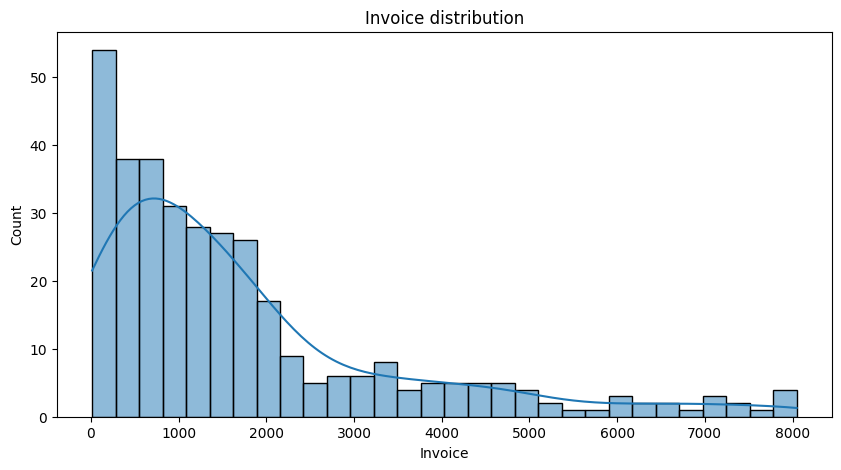

,count,mean,std,min,25%,50%,75%,max
Invoice,343.0,1741.816327,1775.69831,14.0,494.0,1166.0,2098.5,8047.0


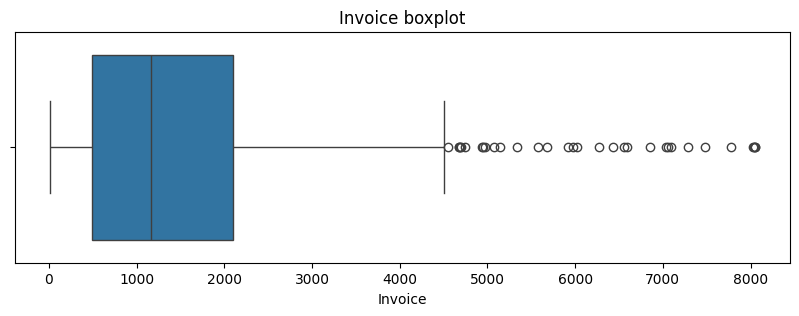

In [23]:
plot_numeric(merged_df, "Invoice", bins=30, title="Invoice distribution")
plot_box(merged_df, "Invoice", title="Invoice boxplot")

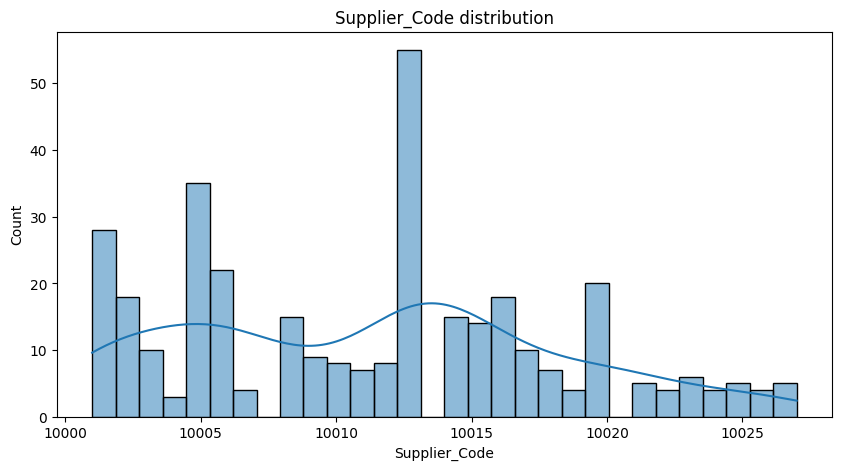

,count,mean,std,min,25%,50%,75%,max
Supplier_Code,343.0,10011.314869,6.91722,10001.0,10005.0,10013.0,10016.0,10027.0


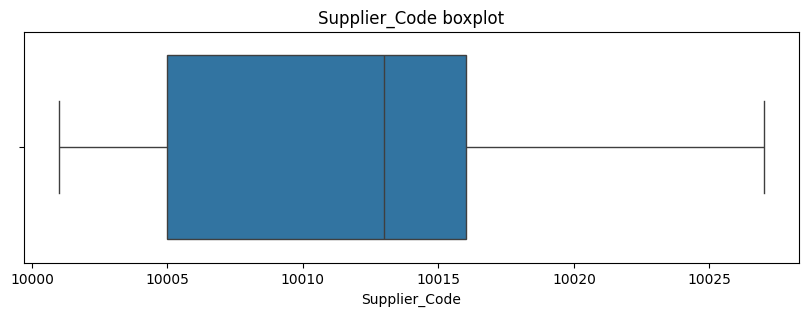

In [24]:
plot_numeric(merged_df, "Supplier_Code", bins=30, title="Supplier_Code distribution")
plot_box(merged_df, "Supplier_Code", title="Supplier_Code boxplot")

In [25]:
summarize_text(merged_df, "Supplier_Name")

,column,non_null_count,unique_count,avg_length,median_length,avg_word_count,median_word_count
0,Supplier_Name,343,28,23.19242,24.0,3.562682,4.0


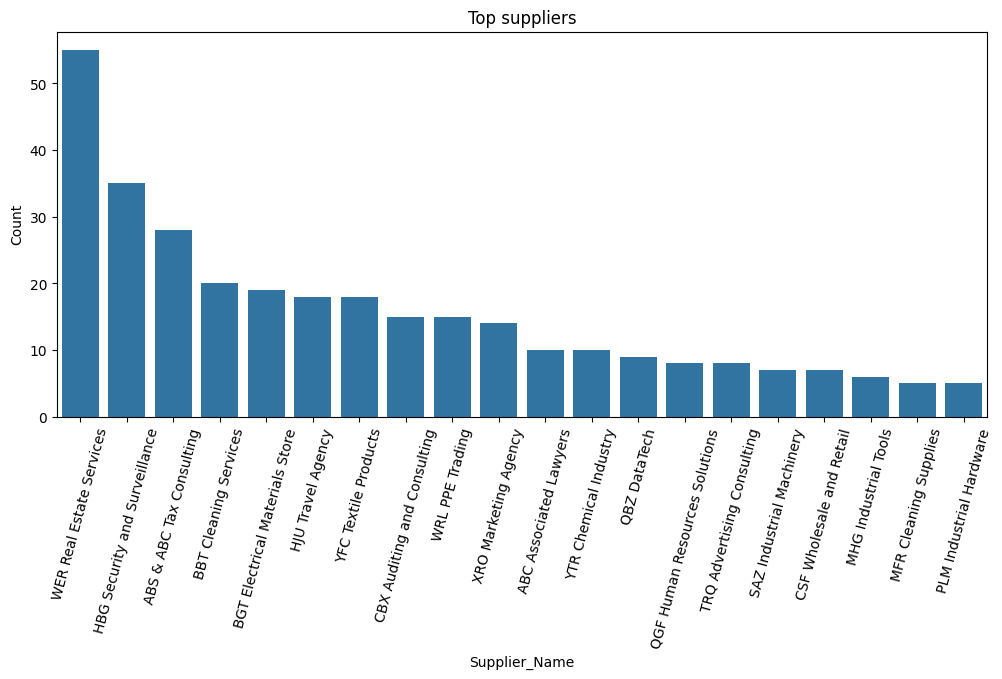

,Supplier_Name,count
0,WER Real Estate Services,55
1,HBG Security and Surveillance,35
2,ABS & ABC Tax Consulting,28
3,BBT Cleaning Services,20
4,BGT Electrical Materials Store,19
5,HJU Travel Agency,18
6,YFC Textile Products,18
7,CBX Auditing and Consulting,15
8,WRL PPE Trading,15
9,XRO Marketing Agency,14


In [26]:
plot_categorical(merged_df, "Supplier_Name", top_n=20, title="Top suppliers")

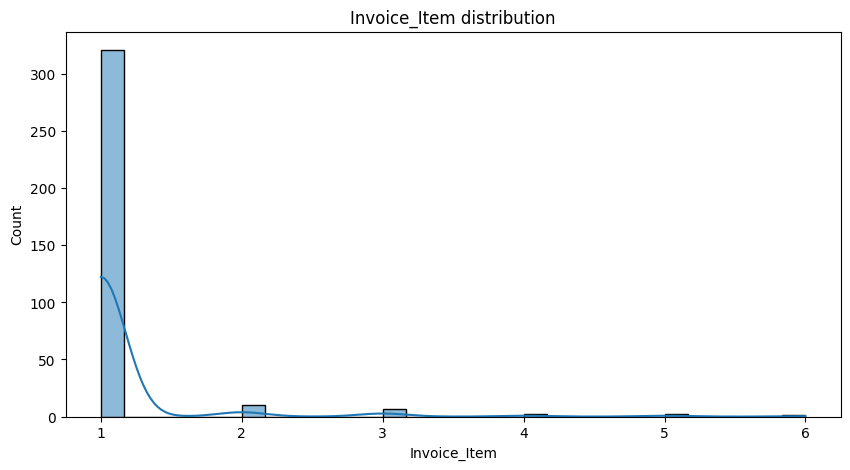

,count,mean,std,min,25%,50%,75%,max
Invoice_Item,343.0,1.125364,0.560934,1.0,1.0,1.0,1.0,6.0


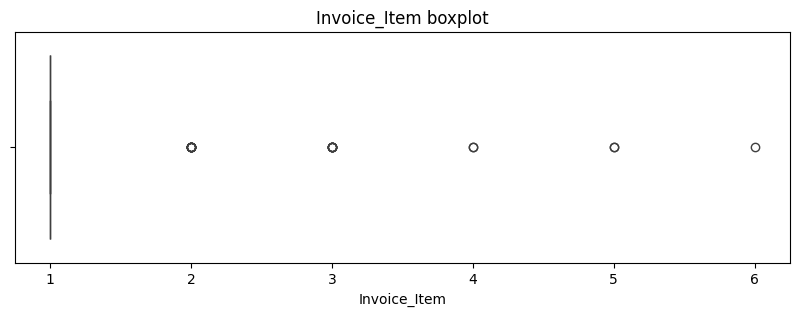

In [27]:
plot_numeric(merged_df, "Invoice_Item", bins=30, title="Invoice_Item distribution")
plot_box(merged_df, "Invoice_Item", title="Invoice_Item boxplot")

In [28]:
summarize_text(merged_df, "Item_Description")

,column,non_null_count,unique_count,avg_length,median_length,avg_word_count,median_word_count
0,Item_Description,343,123,27.218659,26.0,4.145773,4.0


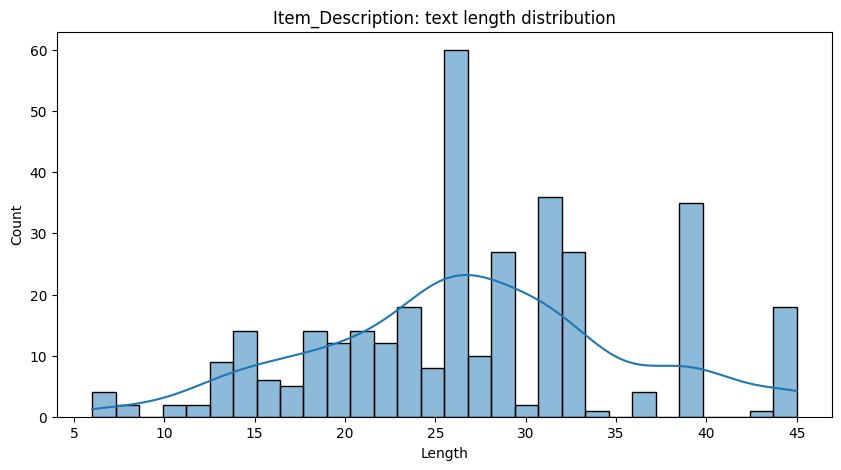

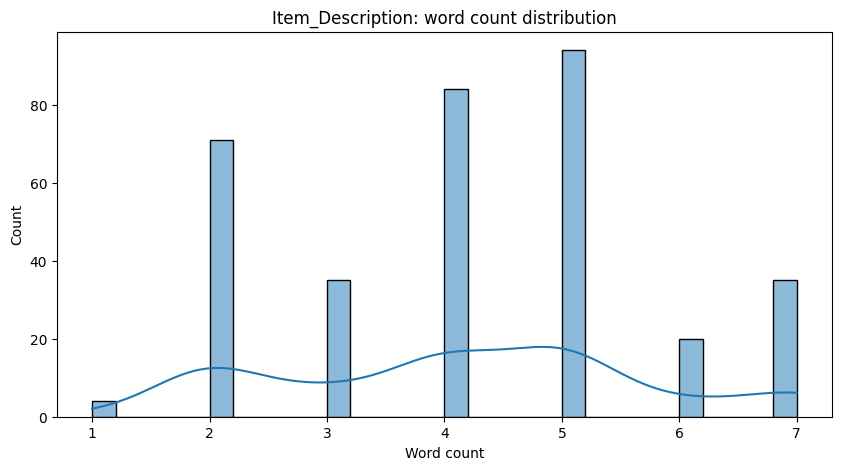

,metric,value
0,avg_length,27.218659
1,median_length,26.000000
2,avg_word_count,4.145773
3,median_word_count,4.000000


In [29]:
plot_text_lengths(merged_df, "Item_Description")

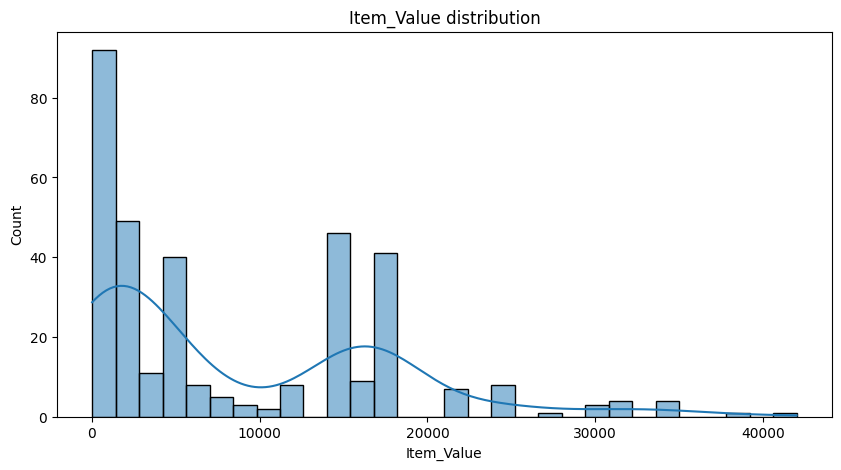

,count,mean,std,min,25%,50%,75%,max
Item_Value,343.0,8715.717201,8975.830724,15.0,1200.0,4500.0,15000.0,42000.0


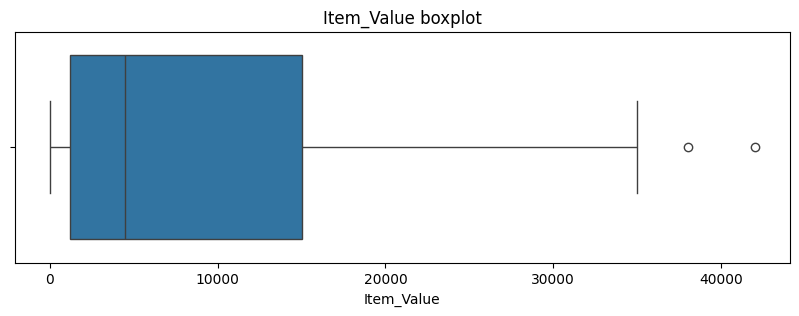

In [30]:
plot_numeric(merged_df, "Item_Value", bins=30, title="Item_Value distribution")
plot_box(merged_df, "Item_Value", title="Item_Value boxplot")

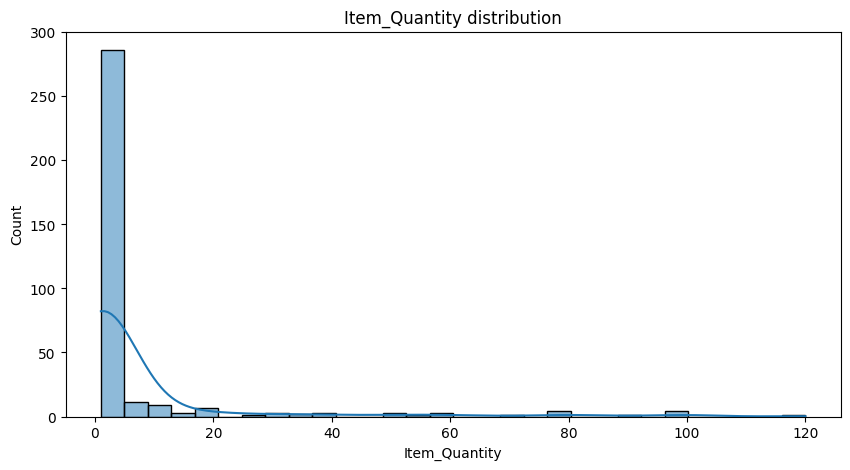

,count,mean,std,min,25%,50%,75%,max
Item_Quantity,343.0,6.865889,18.237856,1.0,1.0,1.0,1.0,120.0


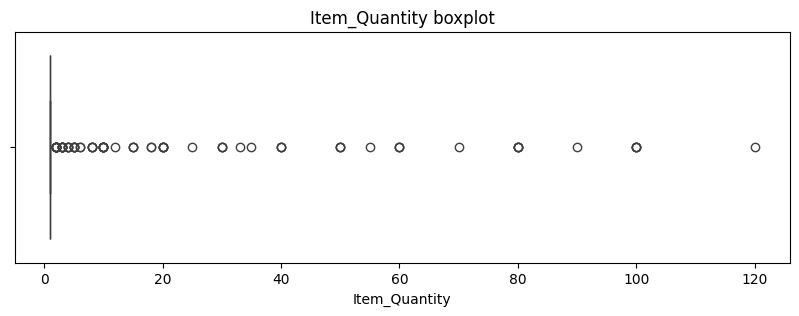

In [31]:
plot_numeric(merged_df, "Item_Quantity", bins=30, title="Item_Quantity distribution")
plot_box(merged_df, "Item_Quantity", title="Item_Quantity boxplot")

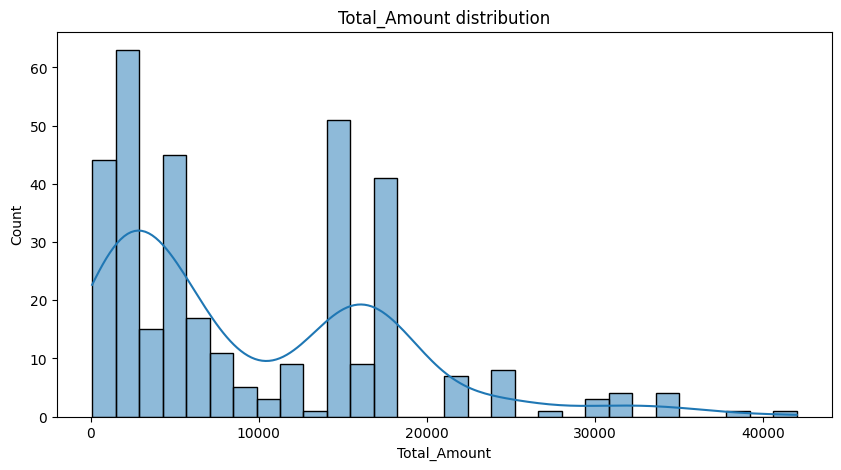

,count,mean,std,min,25%,50%,75%,max
Total_Amount,343.0,9581.023324,8504.378336,96.0,2200.0,6000.0,15000.0,42000.0


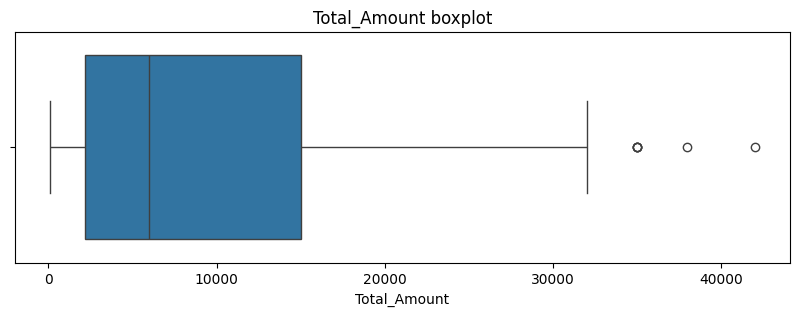

In [32]:
plot_numeric(merged_df, "Total_Amount", bins=30, title="Total_Amount distribution")
plot_box(merged_df, "Total_Amount", title="Total_Amount boxplot")

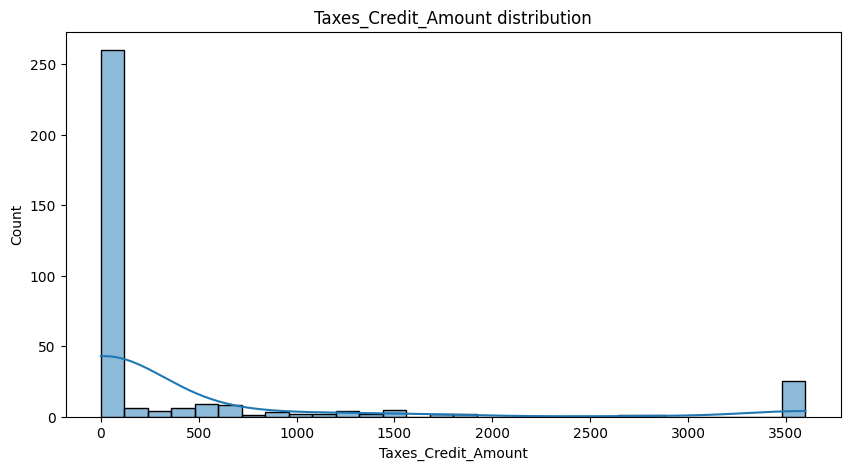

,count,mean,std,min,25%,50%,75%,max
Taxes_Credit_Amount,343.0,408.95102,982.435025,0.0,0.0,0.0,90.0,3600.0


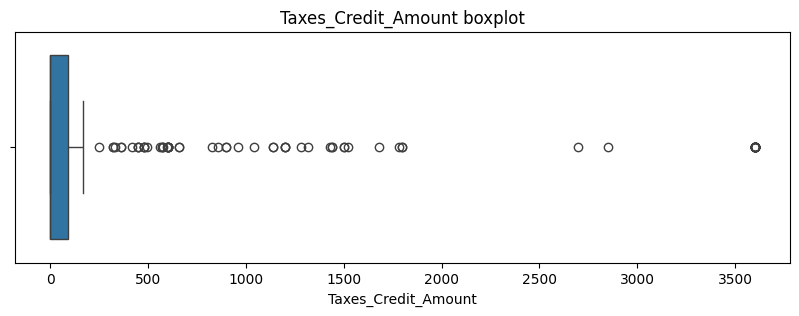

In [33]:
plot_numeric(merged_df, "Taxes_Credit_Amount", bins=30, title="Taxes_Credit_Amount distribution")
plot_box(merged_df, "Taxes_Credit_Amount", title="Taxes_Credit_Amount boxplot")

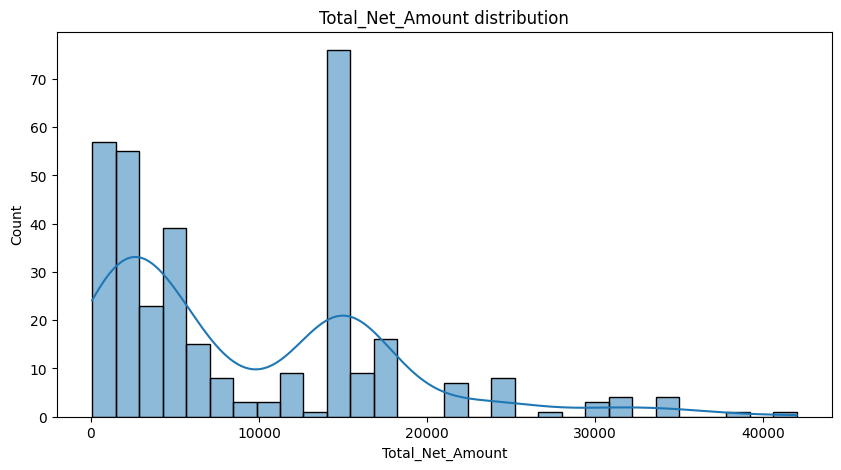

,count,mean,std,min,25%,50%,75%,max
Total_Net_Amount,343.0,9172.072303,8380.653294,76.8,2200.0,5000.0,15000.0,42000.0


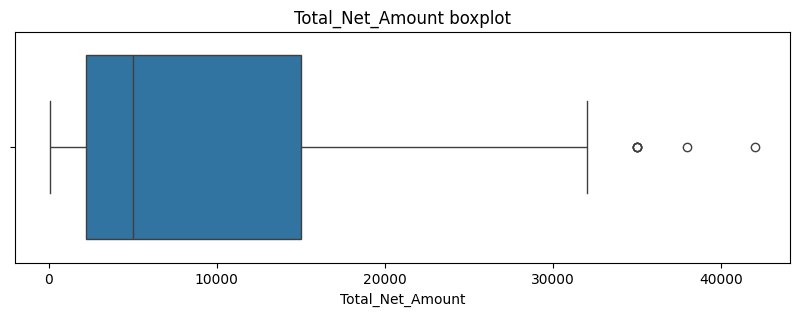

In [34]:
plot_numeric(merged_df, "Total_Net_Amount", bins=30, title="Total_Net_Amount distribution")
plot_box(merged_df, "Total_Net_Amount", title="Total_Net_Amount boxplot")

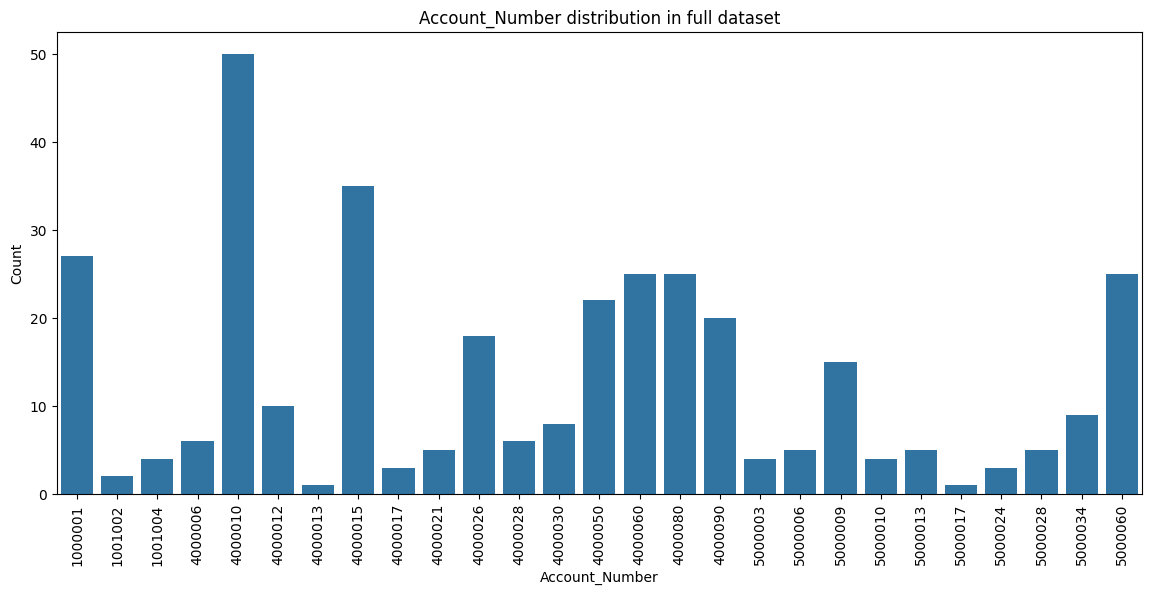

,Account_Number,count
0,4000010,50
1,4000015,35
2,1000001,27
3,4000080,25
4,4000060,25
5,5000060,25
6,4000050,22
7,4000090,20
8,4000026,18
9,5000009,15


In [35]:
account_counts = merged_df["Account_Number"].value_counts().reset_index()
account_counts.columns = ["Account_Number", "count"]
plt.figure(figsize=(14, 6))
sns.barplot(data=account_counts, x="Account_Number", y="count")
plt.title("Account_Number distribution in full dataset")
plt.xlabel("Account_Number")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()
display(account_counts)

In [36]:
summarize_text(merged_df, "Account_Description")

,column,non_null_count,unique_count,avg_length,median_length,avg_word_count,median_word_count
0,Account_Description,343,20,18.848397,20.0,2.379009,2.0


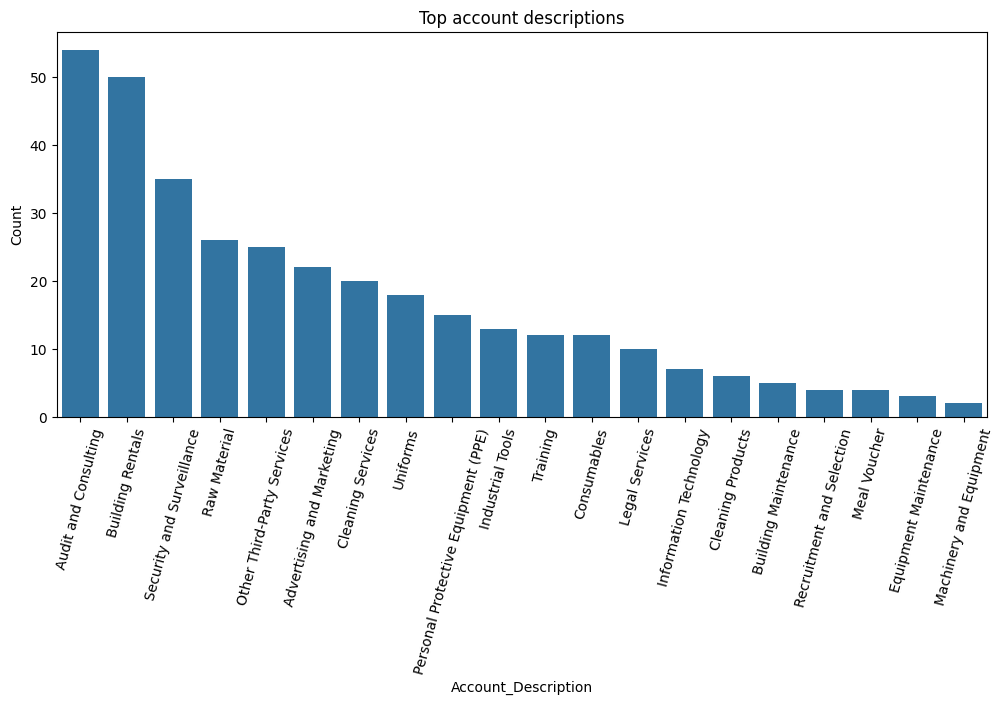

,Account_Description,count
0,Audit and Consulting,54
1,Building Rentals,50
2,Security and Surveillance,35
3,Raw Material,26
4,Other Third-Party Services,25
5,Advertising and Marketing,22
6,Cleaning Services,20
7,Uniforms,18
8,Personal Protective Equipment (PPE),15
9,Industrial Tools,13


In [37]:
plot_categorical(merged_df, "Account_Description", top_n=20, title="Top account descriptions")

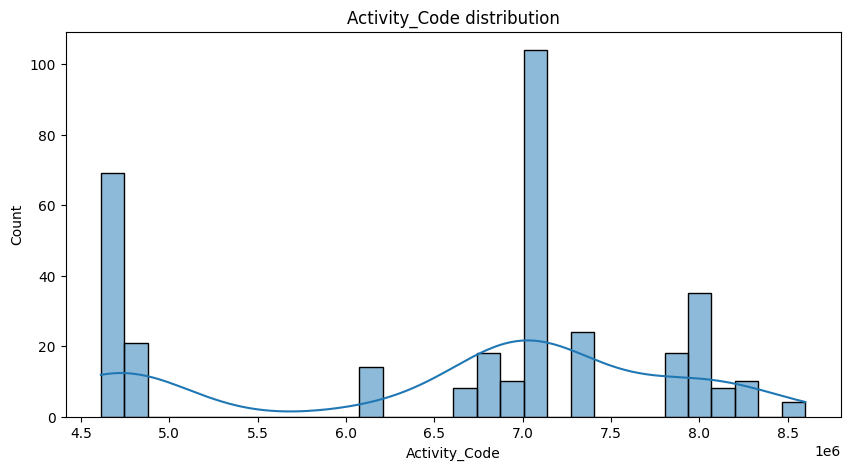

,count,mean,std,min,25%,50%,75%,max
Activity_Code,343.0,6.613859e+06,1.228716e+06,4612500.0,4789052.0,7020400.0,7311400.0,8599604.0


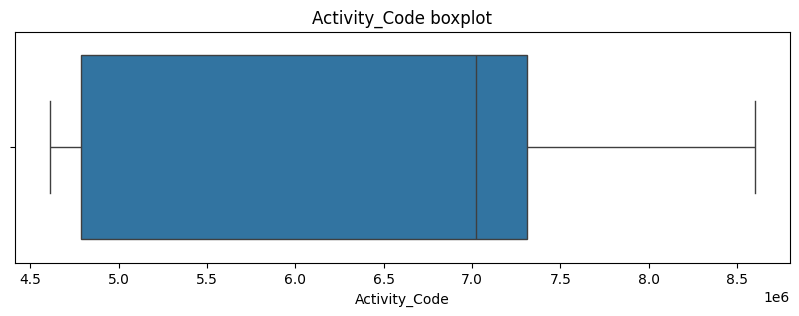

In [38]:
plot_numeric(merged_df, "Activity_Code", bins=30, title="Activity_Code distribution")
plot_box(merged_df, "Activity_Code", title="Activity_Code boxplot")

In [39]:
summarize_text(merged_df, "Activity_Description")

,column,non_null_count,unique_count,avg_length,median_length,avg_word_count,median_word_count
0,Activity_Description,343,21,49.41691,50.0,5.472303,6.0


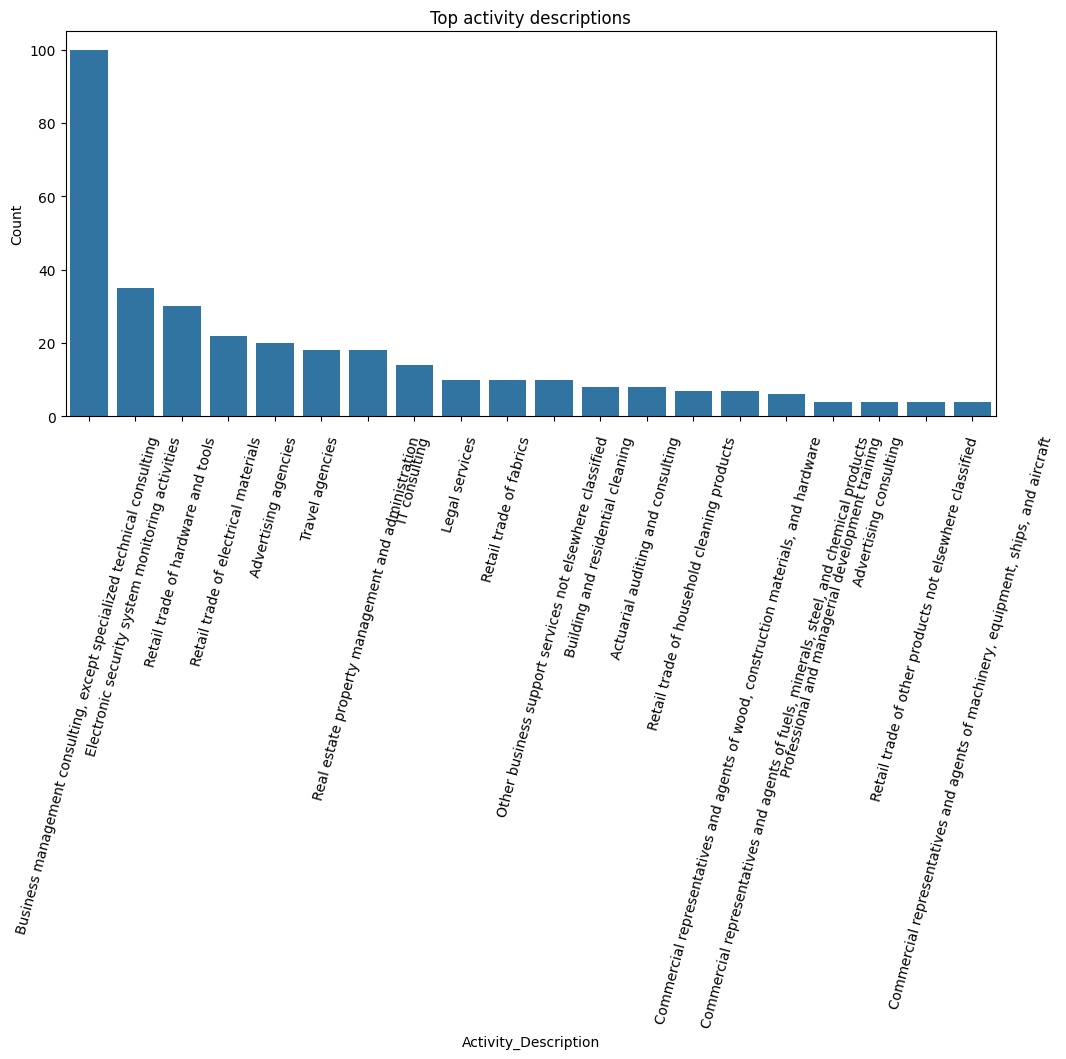

,Activity_Description,count
0,"Business management consulting, except specialized technical consulting",100
1,Electronic security system monitoring activities,35
2,Retail trade of hardware and tools,30
3,Retail trade of electrical materials,22
4,Advertising agencies,20
5,Travel agencies,18
6,Real estate property management and administration,18
7,IT consulting,14
8,Legal services,10
9,Retail trade of fabrics,10


In [40]:
plot_categorical(merged_df, "Activity_Description", top_n=20, title="Top activity descriptions")

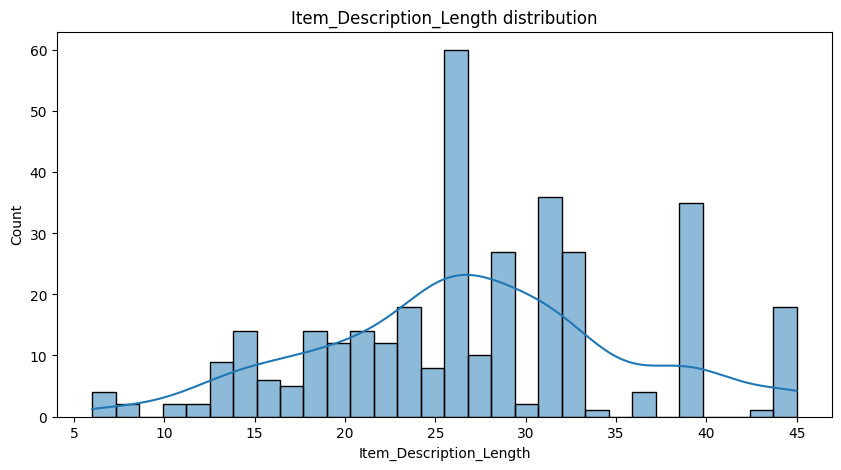

,count,mean,std,min,25%,50%,75%,max
Item_Description_Length,343.0,27.218659,8.493651,6.0,22.0,26.0,32.0,45.0


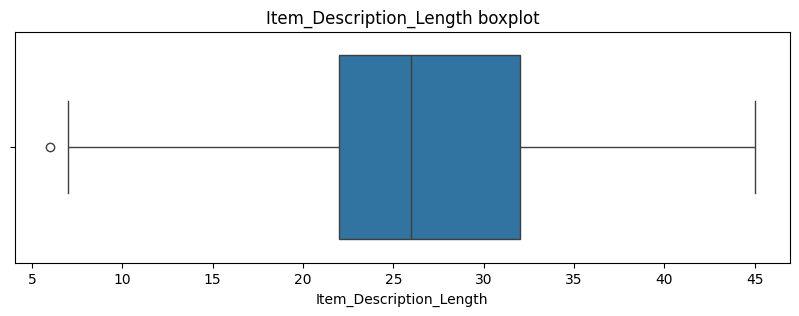

In [41]:
plot_numeric(merged_df, "Item_Description_Length", bins=30, title="Item_Description_Length distribution")
plot_box(merged_df, "Item_Description_Length", title="Item_Description_Length boxplot")

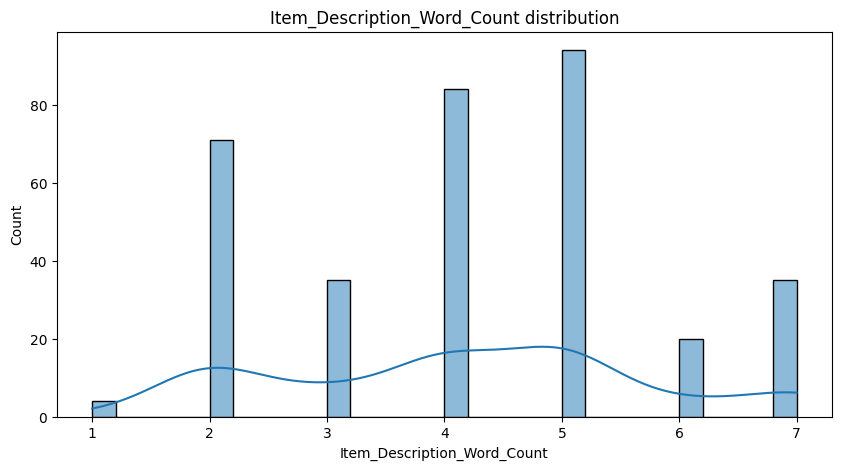

,count,mean,std,min,25%,50%,75%,max
Item_Description_Word_Count,343.0,4.145773,1.564137,1.0,3.0,4.0,5.0,7.0


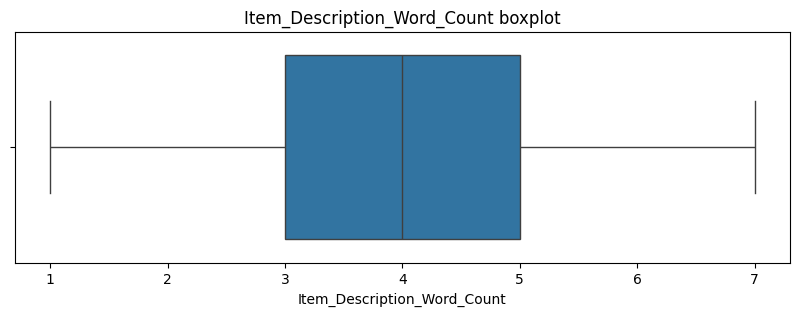

In [42]:
plot_numeric(merged_df, "Item_Description_Word_Count", bins=30, title="Item_Description_Word_Count distribution")
plot_box(merged_df, "Item_Description_Word_Count", title="Item_Description_Word_Count boxplot")

In [43]:
merged_df["Calculated_Total"] = merged_df["Item_Value"] * merged_df["Item_Quantity"]
merged_df["Total_Diff"] = merged_df["Total_Amount"] - merged_df["Calculated_Total"]

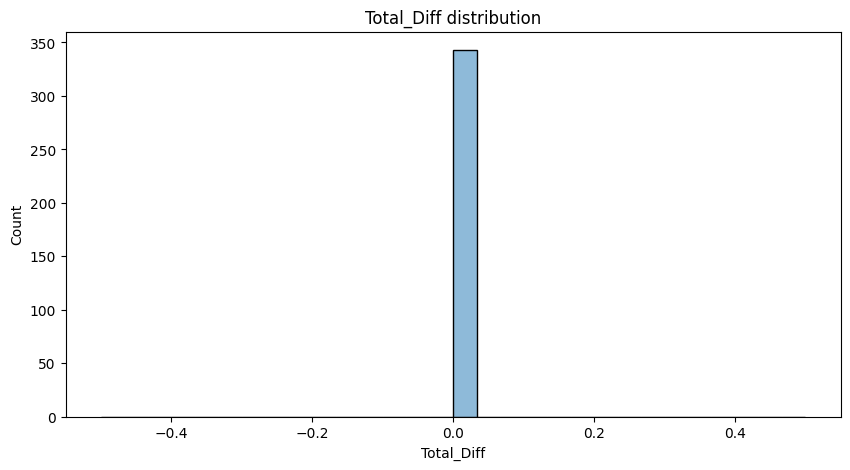

,count,mean,std,min,25%,50%,75%,max
Total_Diff,343.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


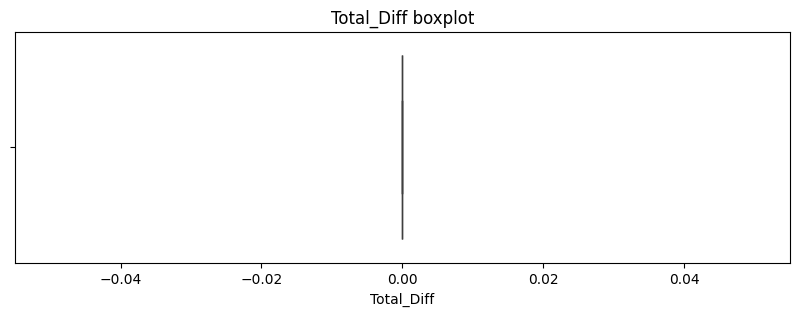

In [44]:
plot_numeric(merged_df, "Total_Diff", bins=30, title="Total_Diff distribution")
plot_box(merged_df, "Total_Diff", title="Total_Diff boxplot")

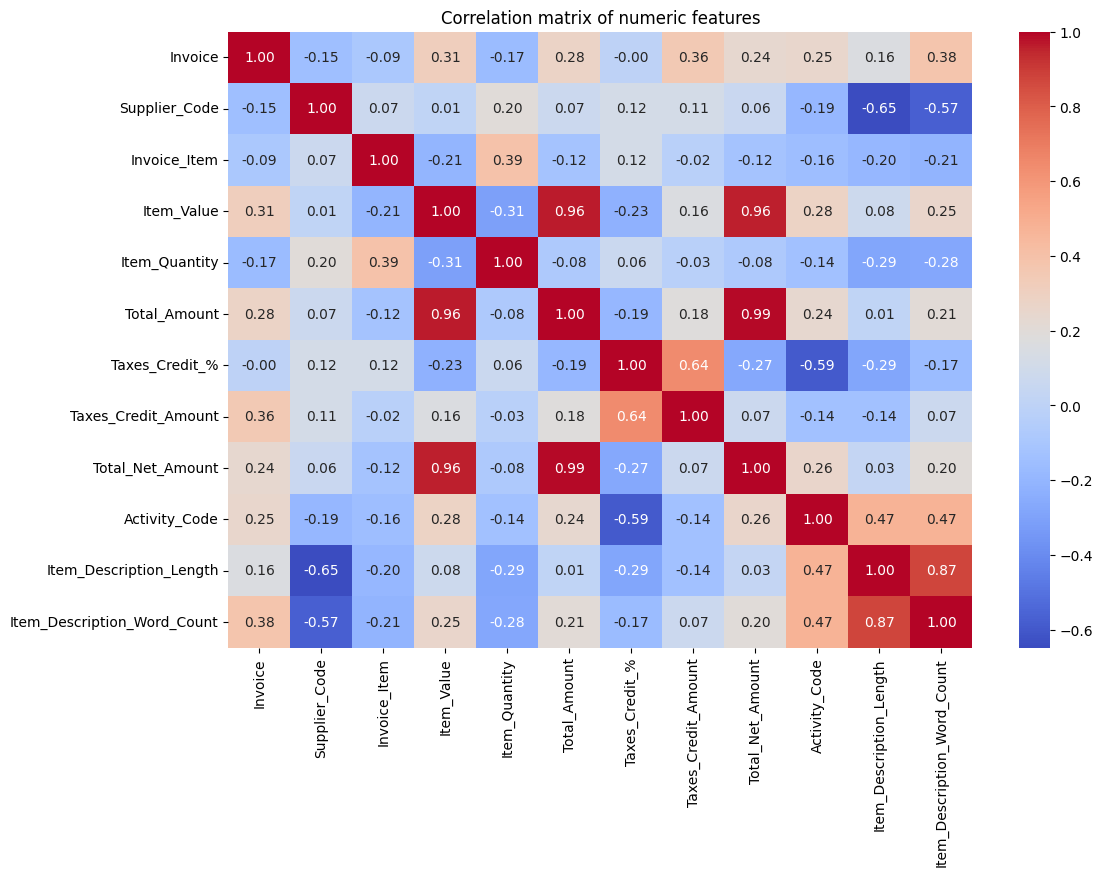

,Invoice,Supplier_Code,Invoice_Item,Item_Value,Item_Quantity,Total_Amount,Taxes_Credit_%,Taxes_Credit_Amount,Total_Net_Amount,Activity_Code,Item_Description_Length,Item_Description_Word_Count
Invoice,1.000000,-0.145935,-0.089303,0.312193,-0.165612,0.275580,-0.001596,0.355555,0.237968,0.249421,0.161185,0.380605
Supplier_Code,-0.145935,1.000000,0.067416,0.014266,0.199431,0.072262,0.115334,0.112354,0.060158,-0.194324,-0.647907,-0.571782
Invoice_Item,-0.089303,0.067416,1.000000,-0.208665,0.391503,-0.122140,0.115503,-0.024751,-0.121042,-0.156503,-0.196636,-0.214182
Item_Value,0.312193,0.014266,-0.208665,1.000000,-0.307924,0.962375,-0.226877,0.159730,0.957858,0.280792,0.078999,0.254478
Item_Quantity,-0.165612,0.199431,0.391503,-0.307924,1.000000,-0.078782,0.062691,-0.026306,-0.076861,-0.137625,-0.286175,-0.278421
Total_Amount,0.275580,0.072262,-0.122140,0.962375,-0.078782,1.000000,-0.191891,0.182782,0.993336,0.237107,0.014313,0.205098
Taxes_Credit_%,-0.001596,0.115334,0.115503,-0.226877,0.062691,-0.191891,1.000000,0.641393,-0.269912,-0.593296,-0.286680,-0.167443
Taxes_Credit_Amount,0.355555,0.112354,-0.024751,0.159730,-0.026306,0.182782,0.641393,1.000000,0.068253,-0.135993,-0.136263,0.070241
Total_Net_Amount,0.237968,0.060158,-0.121042,0.957858,-0.076861,0.993336,-0.269912,0.068253,1.000000,0.256549,0.030498,0.199892
Activity_Code,0.249421,-0.194324,-0.156503,0.280792,-0.137625,0.237107,-0.593296,-0.135993,0.256549,1.000000,0.473655,0.473027


In [45]:
corr_cols = [
    "Invoice",
    "Supplier_Code",
    "Invoice_Item",
    "Item_Value",
    "Item_Quantity",
    "Total_Amount",
    "Taxes_Credit_%",
    "Taxes_Credit_Amount",
    "Total_Net_Amount",
    "Activity_Code",
    "Item_Description_Length",
    "Item_Description_Word_Count"
]
corr_matrix = merged_df[corr_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation matrix of numeric features")
plt.show()

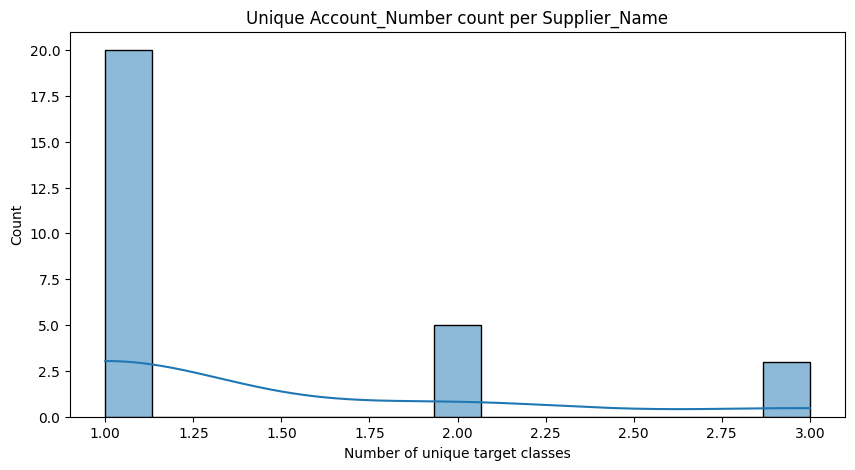

,Supplier_Name,target_count
0,ABC Associated Lawyers,1
1,ABS & ABC Tax Consulting,1
2,ATY Business Consulting,1
3,BBT Cleaning Services,1
5,BGT Electrical Materials Trading,1
6,CBJ Corporate Training,1
7,CBX Auditing and Consulting,1
11,HJU Travel Agency,1
15,PKM Quality Systems Auditing,1
10,HBG Security and Surveillance,1


,Supplier_Name,target_count
21,SAZ Industrial Machinery,3
23,WER Real Estate Services,3
19,QGF Human Resources Solutions,3
8,CBZ Recruitment Advisory,2
14,MHG Industrial Tools,2
9,CSF Wholesale and Retail,2
4,BGT Electrical Materials Store,2
18,QBZ DataTech,2
3,BBT Cleaning Services,1
2,ATY Business Consulting,1


In [46]:
supplier_target_diversity = (
    merged_df.groupby("Supplier_Name")["Account_Number"]
    .nunique()
    .reset_index(name="target_count")
)
plt.figure(figsize=(10, 5))
sns.histplot(supplier_target_diversity["target_count"], bins=15, kde=True)
plt.title("Unique Account_Number count per Supplier_Name")
plt.xlabel("Number of unique target classes")
plt.ylabel("Count")
plt.show()
display(supplier_target_diversity.sort_values("target_count").head(20))
display(supplier_target_diversity.sort_values("target_count", ascending=False).head(20))

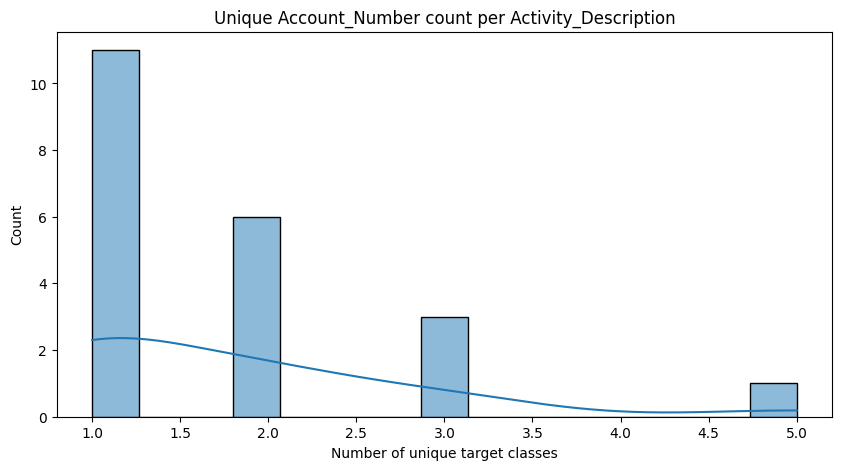

,Activity_Description,target_count
0,Actuarial auditing and consulting,1
1,Advertising agencies,1
2,Advertising consulting,1
6,"Commercial representatives and agents of machinery, equipment, ships, and aircraft",1
12,Professional and managerial development training,1
13,Real estate property management and administration,1
10,Legal services,1
8,Electronic security system monitoring activities,1
15,Retail trade of fabrics,1
19,Technical expertise services related to occupational safety,1


,Activity_Description,target_count
4,"Business management consulting, except specialized technical consulting",5
3,Building and residential cleaning,3
9,IT consulting,3
17,Retail trade of household cleaning products,3
11,Other business support services not elsewhere classified,2
16,Retail trade of hardware and tools,2
18,Retail trade of other products not elsewhere classified,2
14,Retail trade of electrical materials,2
5,"Commercial representatives and agents of fuels, minerals, steel, and chemical products",2
7,"Commercial representatives and agents of wood, construction materials, and hardware",2


In [47]:
activity_target_diversity = (
    merged_df.groupby("Activity_Description")["Account_Number"]
    .nunique()
    .reset_index(name="target_count")
)
plt.figure(figsize=(10, 5))
sns.histplot(activity_target_diversity["target_count"], bins=15, kde=True)
plt.title("Unique Account_Number count per Activity_Description")
plt.xlabel("Number of unique target classes")
plt.ylabel("Count")
plt.show()
display(activity_target_diversity.sort_values("target_count").head(20))
display(activity_target_diversity.sort_values("target_count", ascending=False).head(20))

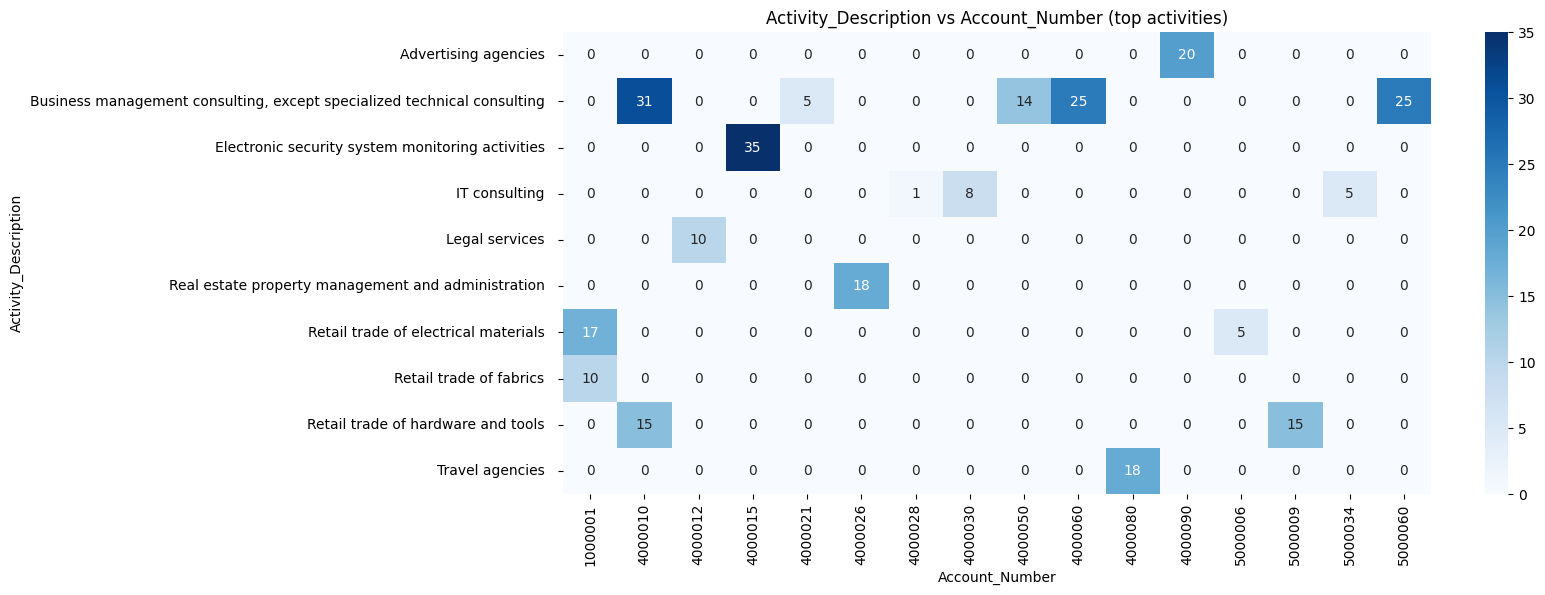

Account_Number,1000001,4000010,4000012,4000015,4000021,4000026,4000028,4000030,4000050,4000060,4000080,4000090,5000006,5000009,5000034,5000060
Activity_Description,,,,,,,,,,,,,,,,
Advertising agencies,0,0,0,0,0,0,0,0,0,0,0,20,0,0,0,0
"Business management consulting, except specialized technical consulting",0,31,0,0,5,0,0,0,14,25,0,0,0,0,0,25
Electronic security system monitoring activities,0,0,0,35,0,0,0,0,0,0,0,0,0,0,0,0
IT consulting,0,0,0,0,0,0,1,8,0,0,0,0,0,0,5,0
Legal services,0,0,10,0,0,0,0,0,0,0,0,0,0,0,0,0
Real estate property management and administration,0,0,0,0,0,18,0,0,0,0,0,0,0,0,0,0
Retail trade of electrical materials,17,0,0,0,0,0,0,0,0,0,0,0,5,0,0,0
Retail trade of fabrics,10,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Retail trade of hardware and tools,0,15,0,0,0,0,0,0,0,0,0,0,0,15,0,0


In [48]:
top_activities = merged_df["Activity_Description"].value_counts().head(10).index
activity_account_ct = pd.crosstab(
    merged_df.loc[merged_df["Activity_Description"].isin(top_activities), "Activity_Description"],
    merged_df.loc[merged_df["Activity_Description"].isin(top_activities), "Account_Number"]
)
plt.figure(figsize=(14, 6))
sns.heatmap(activity_account_ct, annot=True, fmt="d", cmap="Blues")
plt.title("Activity_Description vs Account_Number (top activities)")
plt.xlabel("Account_Number")
plt.ylabel("Activity_Description")
plt.show()
display(activity_account_ct)

In [49]:
numeric_cols = [
    "Invoice",
    "Supplier_Code",
    "Invoice_Item",
    "Item_Value",
    "Item_Quantity",
    "Total_Amount",
    "Taxes_Credit_%",
    "Taxes_Credit_Amount",
    "Total_Net_Amount",
    "Activity_Code",
    "Item_Description_Length",
    "Item_Description_Word_Count"
]
compare_numeric = []
for col in numeric_cols:
    compare_numeric.append({
        "column": col,
        "train_mean": train_df[col].mean() if col in train_df.columns else np.nan,
        "test_mean": test_df[col].mean() if col in test_df.columns else np.nan,
        "train_median": train_df[col].median() if col in train_df.columns else np.nan,
        "test_median": test_df[col].median() if col in test_df.columns else np.nan
    })
compare_numeric_df = pd.DataFrame(compare_numeric)
display(compare_numeric_df)

,column,train_mean,test_mean,train_median,test_median
0,Invoice,1.708353e+03,1.933412e+03,1113.0,1400.0
1,Supplier_Code,1.001110e+04,1.001257e+04,10013.0,10013.0
2,Invoice_Item,1.085616e+00,1.352941e+00,1.0,1.0
3,Item_Value,9.018086e+03,6.984510e+03,4500.0,3200.0
4,Item_Quantity,6.921233e+00,6.549020e+00,1.0,1.0
5,Total_Amount,9.893082e+03,7.794333e+03,6000.0,4500.0
6,Taxes_Credit_%,5.650685e+00,8.235294e+00,0.0,0.0
7,Taxes_Credit_Amount,4.232158e+02,3.272784e+02,0.0,0.0
8,Total_Net_Amount,9.469866e+03,7.467055e+03,6000.0,3600.0
9,Activity_Code,6.700161e+06,6.119732e+06,7020400.0,6621502.0


In [50]:
text_compare_df = pd.DataFrame({
    "column": ["Supplier_Name", "Item_Description", "Activity_Description"],
    "train_unique": [
        train_df["Supplier_Name"].nunique(),
        train_df["Item_Description"].nunique(),
        train_df["Activity_Description"].nunique()
    ],
    "test_unique": [
        test_df["Supplier_Name"].nunique(),
        test_df["Item_Description"].nunique(),
        test_df["Activity_Description"].nunique()
    ]
})
display(text_compare_df)

,column,train_unique,test_unique
0,Supplier_Name,28,27
1,Item_Description,101,50
2,Activity_Description,21,21


## Итоги EDA

В ходе EDA были изучены все основные колонки объединенного датасета, а также отдельно рассмотрены обучающая (`Training`) и тестовая (`Test`) части выборки.

### Основные выводы
1. Колонка `Dataset` задает готовое разбиение на train/test и не должна использоваться как входной признак модели.
2. Целевая переменная `Account_Number` имеет дисбаланс классов, что нужно учитывать при обучении и оценке модели.
3. Наиболее содержательными текстовыми признаками являются `Item_Description`, `Supplier_Name` и `Activity_Description`.
4. Числовые признаки имеют разный масштаб и содержат потенциальные выбросы, что потребует корректной обработки на этапе preprocessing.
5. Поле `Account_Description` нельзя использовать как входной признак, так как оно связано с целевой переменной и при этом не полностью консистентно.
6. Признаки `Supplier_Name` и `Activity_Description` потенциально сильные, но требуют осторожности из-за возможного переобучения на сущностях.
7. Следующим этапом будет preprocessing: отбор признаков, подготовка train/test, кодирование и построение baseline-модели.